In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/glass.csv")

# fixing data types
df['Type'] = df['Type'].astype('category')

# removing K and Ca columns (very low correlation)
df = df.drop(["K", "Ca"], axis=1)

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, roc_auc_score

X, y = df.drop("Type", axis=1), df["Type"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

tree = DecisionTreeClassifier(criterion="entropy", min_samples_split=20)
tree.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsa

In [47]:
y_pred = tree.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.64      0.56      0.60        16
           2       0.50      0.50      0.50        16
           3       0.00      0.00      0.00         1
           5       0.40      0.50      0.44         4
           6       1.00      0.50      0.67         2
           7       0.60      0.75      0.67         4

    accuracy                           0.53        43
   macro avg       0.52      0.47      0.48        43
weighted avg       0.56      0.53      0.54        43



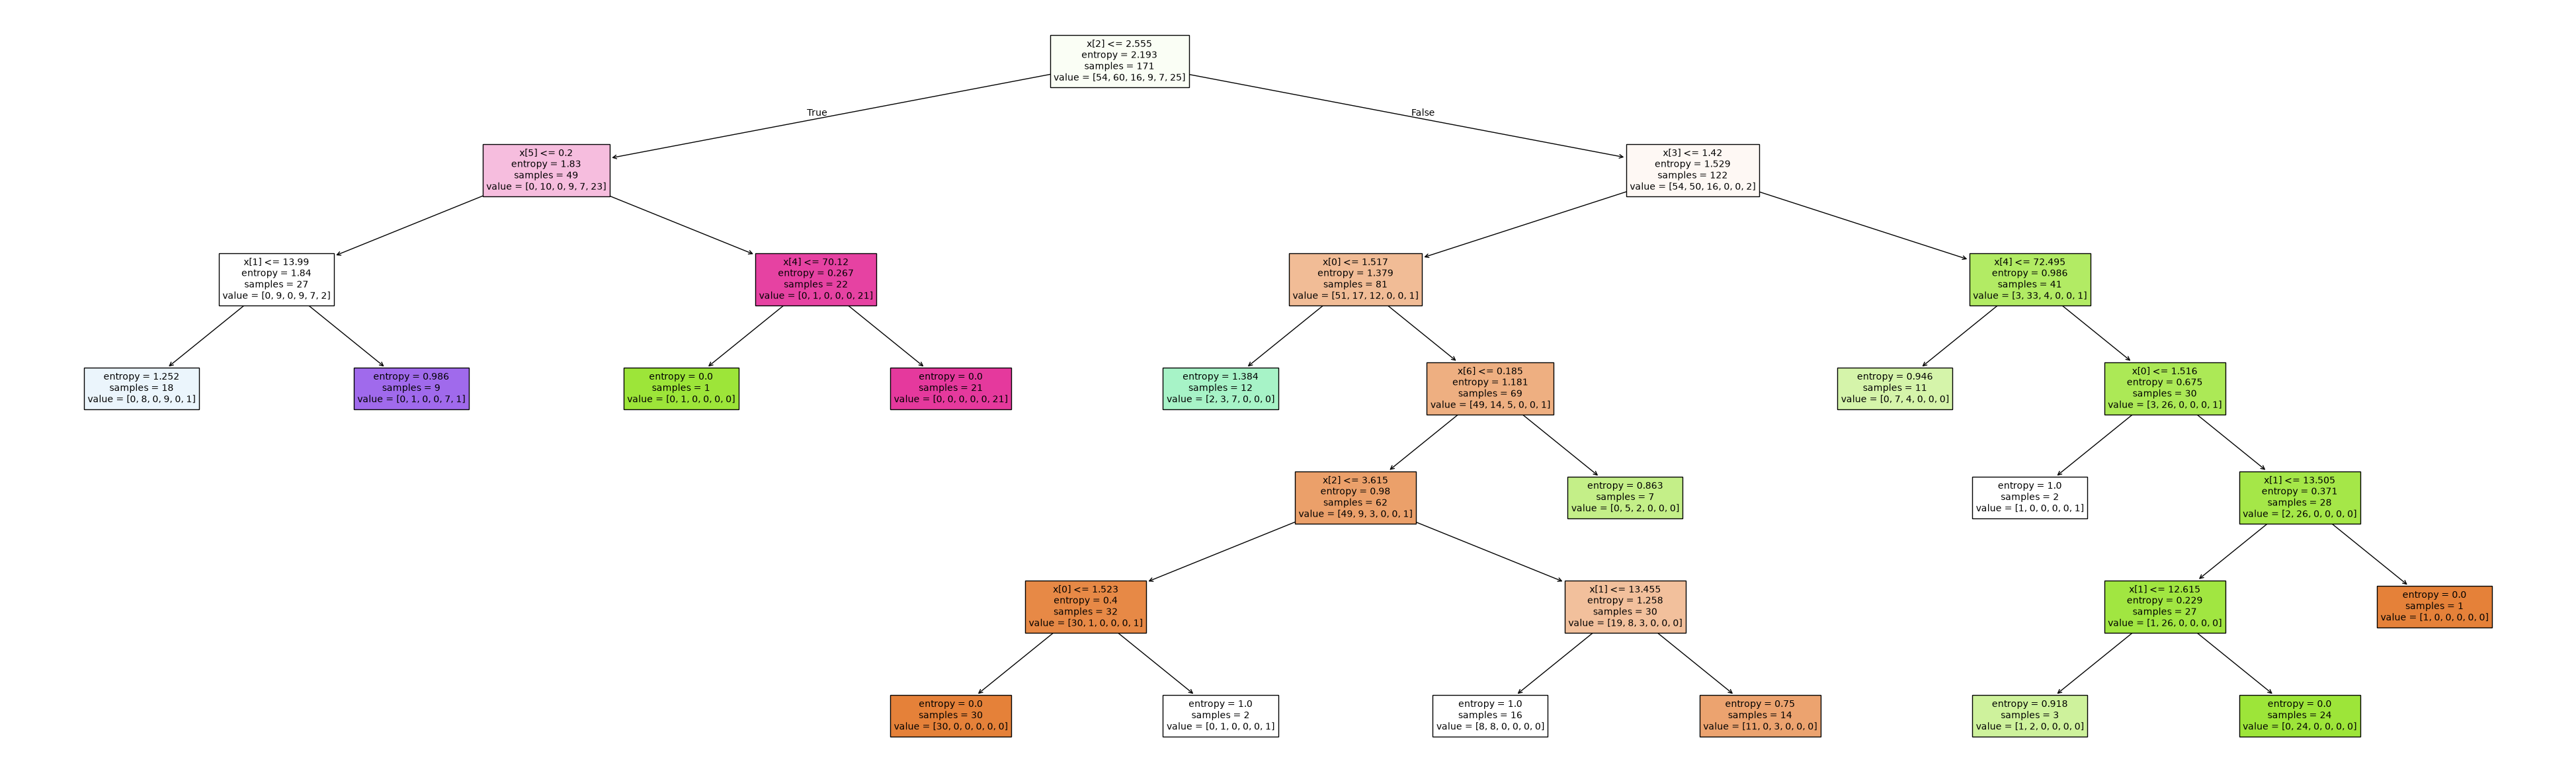

In [48]:
_, ax = plt.subplots(figsize=(50, 15))

plot_tree(
    decision_tree=tree,
    filled=True,
    fontsize=10,
)
plt.show()

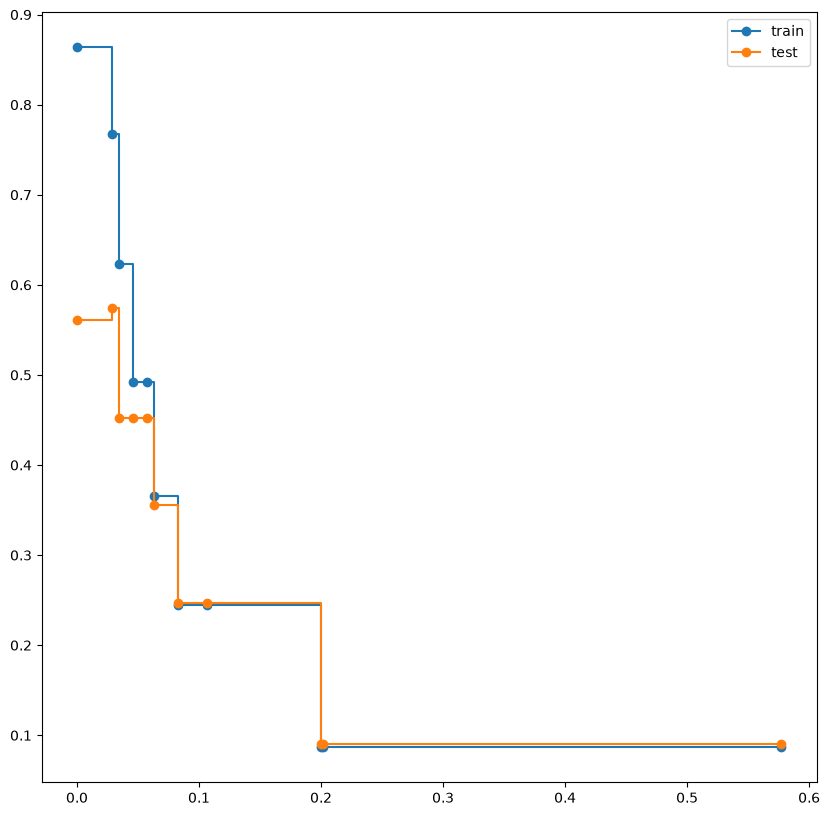

In [49]:
from sklearn.metrics import f1_score

path = tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(max_depth=5, ccp_alpha=ccp_alpha)
    clf.fit(X_train, y_train)
    clfs.append(clf)

train_scores = [f1_score(y_train, clf.predict(X_train), average="macro") for clf in clfs]
test_scores = [f1_score(y_test, clf.predict(X_test), average="macro") for clf in clfs]

_, ax = plt.subplots(figsize=(10, 10))
ax.plot(ccp_alphas, train_scores, marker="o", drawstyle="steps-post", label="train")
ax.plot(ccp_alphas, test_scores, marker="o", drawstyle="steps-post", label="test")

ax.legend()

In [50]:
# stratified cross-validation
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# train model
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier()

cross_val_score(model, X, y, cv=kfold)

array([0.58139535, 0.55813953, 0.58139535, 0.76744186, 0.64285714])

In [59]:
# ensemble
from sklearn.ensemble import RandomForestClassifier

# model
model = RandomForestClassifier(n_estimators=100, random_state=0)

# train
model.fit(X_train, y_train)

# predict
y_pred = model.predict(X_test)

# score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")
f1score = f1_score(y_test, y_pred, average="weighted")
print(f"F1 Score: {f1score:.2f}")

Accuracy: 0.74
F1 Score: 0.71
